# Inteligencia Artificial Aplicada
## Clase 2: Regresión Multivariada - SOLUCIÓN COMPLETA

**Objetivos de la clase:**
- Comprender la regresión lineal multivariada
- Implementar la ecuación normal desde cero con NumPy
- Implementar Gradiente Descendente desde cero
- Usar scikit-learn para regresión
- Entender el problema de las escalas y la normalización

**Contenido:**
1. Cargar y visualizar California Housing
2. Implementar regresión lineal con NumPy
3. Implementar Gradiente Descendente
4. Ejemplo con datos de ventas (pandas + sklearn)
5. El problema de las escalas
6. Normalización como solución

## 1. Cargar y Visualizar California Housing

In [1]:
# Importar librerías necesarias
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar visualización
%matplotlib inline
sns.set_style('whitegrid')

# Cargar California Housing
data = fetch_california_housing()

# Crear DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Mostrar primeras filas
print("Primeras 5 filas:")
df.head()

Primeras 5 filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
df.describe()

Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [3]:
# Información del DataFrame
print("Información del DataFrame:")
df.info()

# Nombres de las características
print("\nCaracterísticas:", data.feature_names)
print("Variable objetivo:", data.target_names[0])

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Características: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Variable objetivo: MedHouseVal


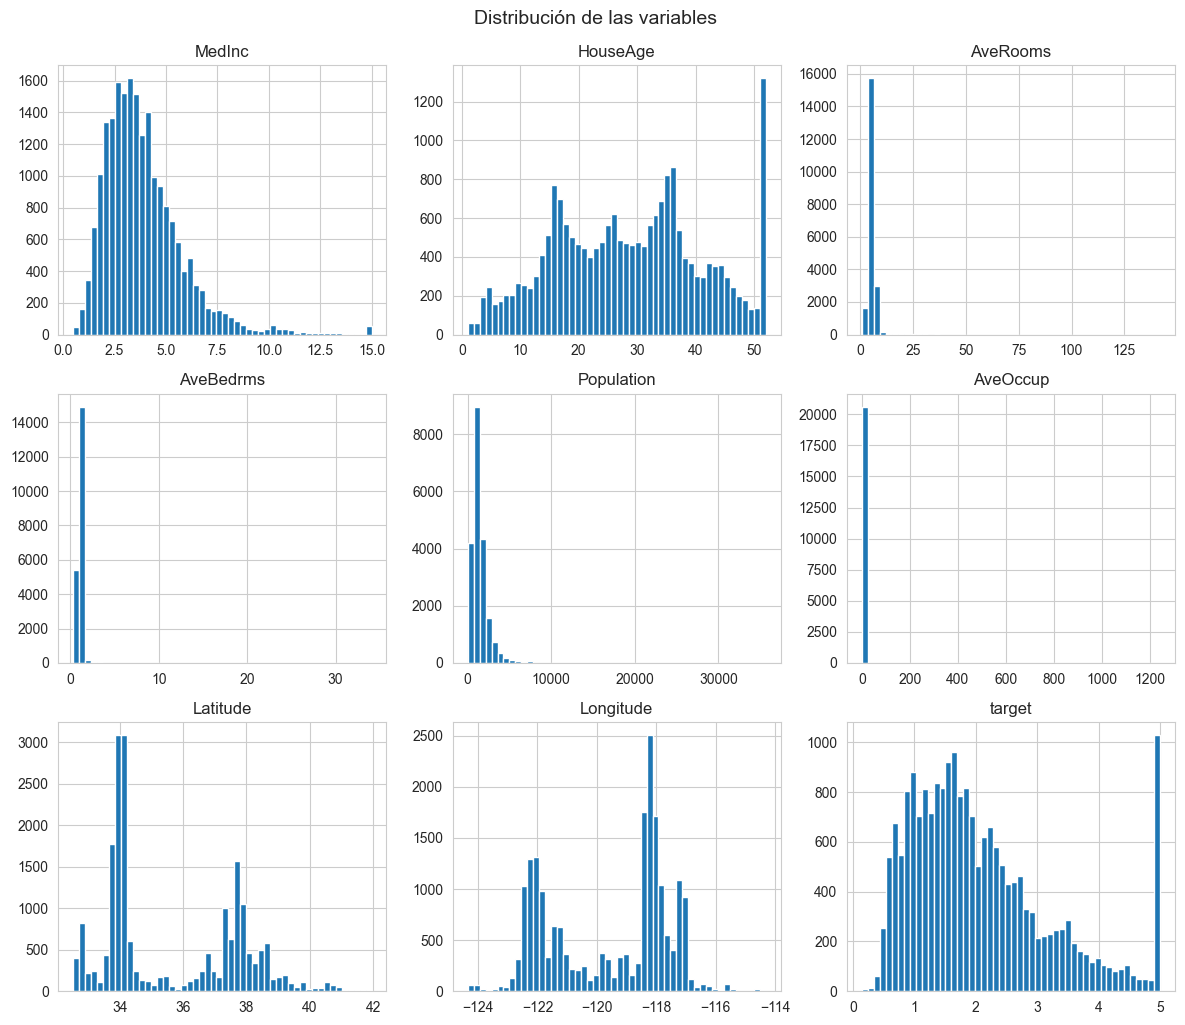

In [4]:
# Histogramas de las variables
df.hist(figsize=(12, 10), bins=50)
plt.tight_layout()
plt.suptitle('Distribución de las variables', y=1.02, fontsize=14)
plt.show()

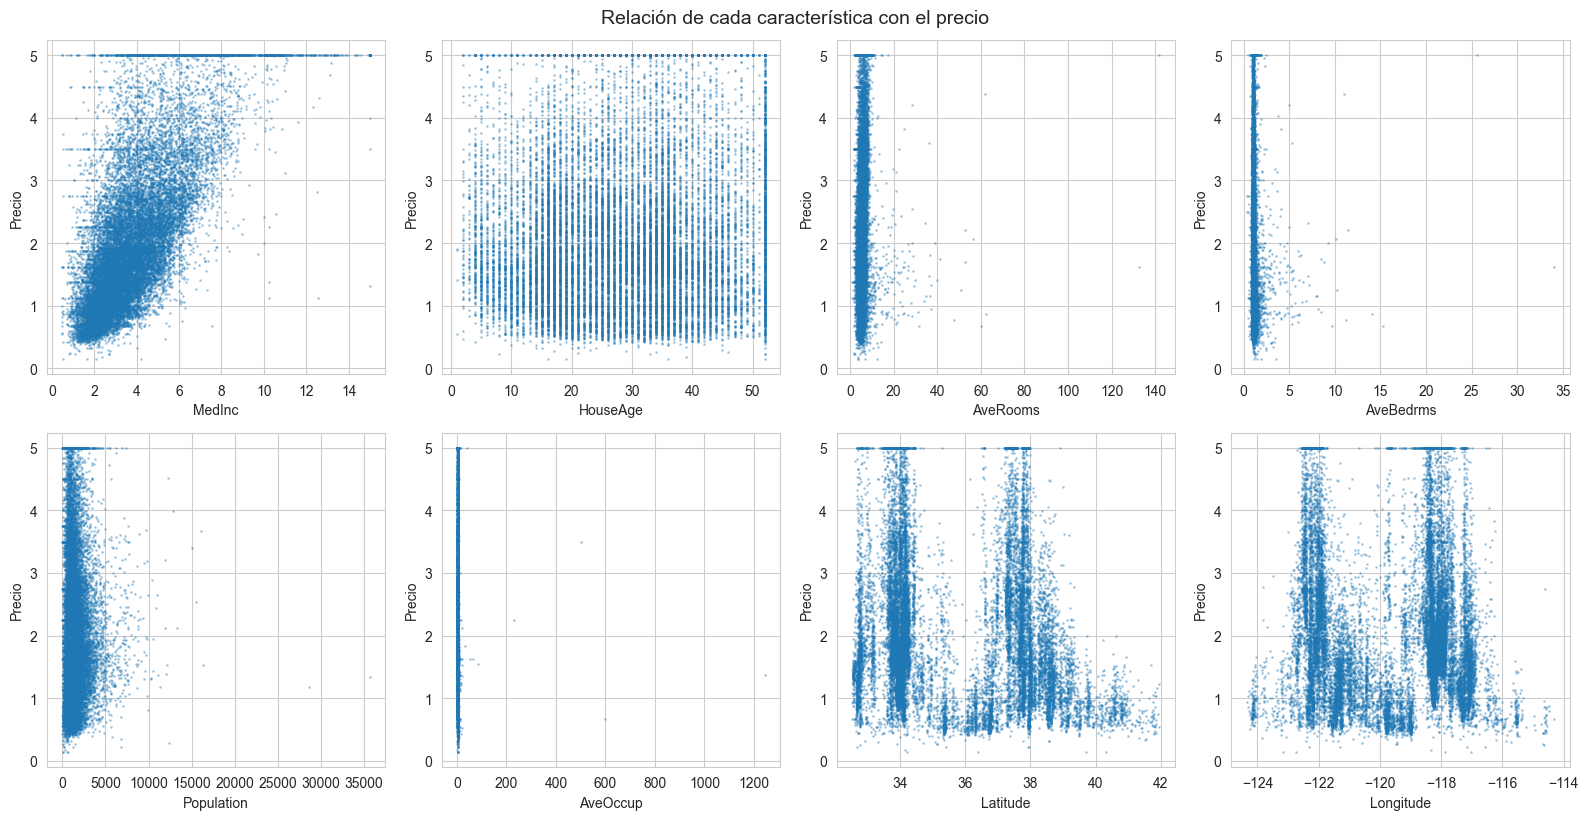

In [5]:
# Scatter plots de cada característica vs target
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.scatter(df.iloc[:, i], df['target'], alpha=0.3, s=1)
    ax.set_xlabel(df.columns[i])
    ax.set_ylabel('Precio')
plt.tight_layout()
plt.suptitle('Relación de cada característica con el precio', y=1.02, fontsize=14)
plt.show()

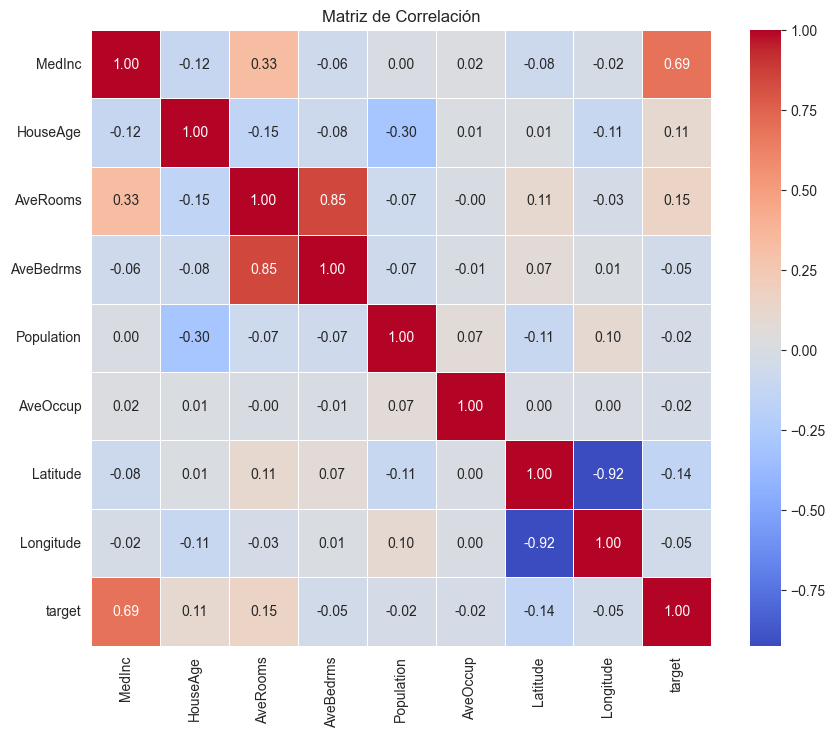

In [6]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

**Observaciones:**
- MedInc tiene la correlación más fuerte con el precio (~0.69)
- Las variables tienen rangos muy diferentes (Population va de 3 a 35,682)
- Latitude y Longitude tienen correlaciones negativas con el precio

## 2. Implementar Regresión Lineal con NumPy

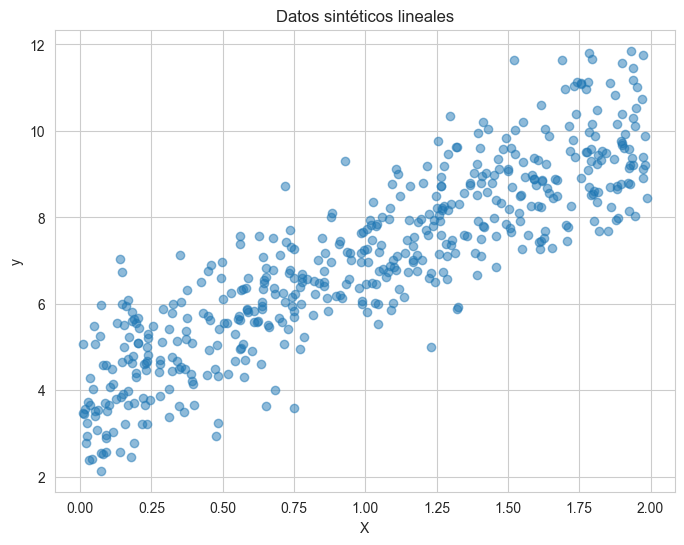

In [7]:
# Generar datos sintéticos
np.random.seed(42)
N = 500
X = 2 * np.random.rand(N, 1)
y = 4 + 3 * X + np.random.randn(N, 1)

# Visualizar los datos
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Datos sintéticos lineales')
plt.show()

In [8]:
# Construir matriz de diseño (con columna de unos para el bias)
A = np.hstack((np.ones((len(X), 1)), X))

# Solución usando ecuación normal
w_normal = np.linalg.inv(A.T @ A) @ A.T @ y

# Solución usando pseudoinversa (más estable)
w_pinv = np.linalg.pinv(A) @ y

print(f"Coeficientes (Ec. Normal): w0 = {w_normal[0,0]:.4f}, w1 = {w_normal[1,0]:.4f}")
print(f"Coeficientes (Pseudoinversa): w0 = {w_pinv[0,0]:.4f}, w1 = {w_pinv[1,0]:.4f}")
print(f"Coeficientes reales: w0 = 4.0000, w1 = 3.0000")

Coeficientes (Ec. Normal): w0 = 3.8929, w1 = 3.1150
Coeficientes (Pseudoinversa): w0 = 3.8929, w1 = 3.1150
Coeficientes reales: w0 = 4.0000, w1 = 3.0000


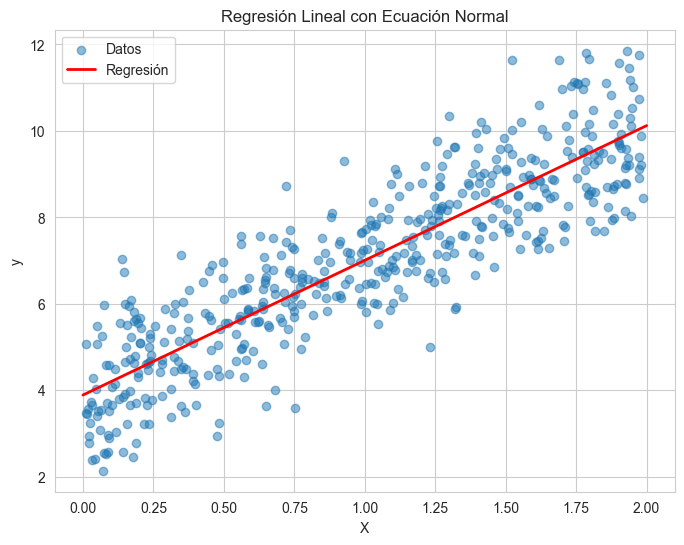

In [9]:
# Predicciones
X_pred = np.linspace(0, 2, 100).reshape(-1, 1)
X_pred_bias = np.hstack((np.ones((len(X_pred), 1)), X_pred))
y_pred = X_pred_bias @ w_pinv

# Visualizar
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, label='Datos')
plt.plot(X_pred, y_pred, 'r-', linewidth=2, label='Regresión')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regresión Lineal con Ecuación Normal')
plt.legend()
plt.show()

Coeficientes polinomiales: w0 = 3.7207, w1 = 3.6622, w2 = 5.7235
Coeficientes reales: w0 = 4.0000, w1 = 3.0000, w2 = 6.0000


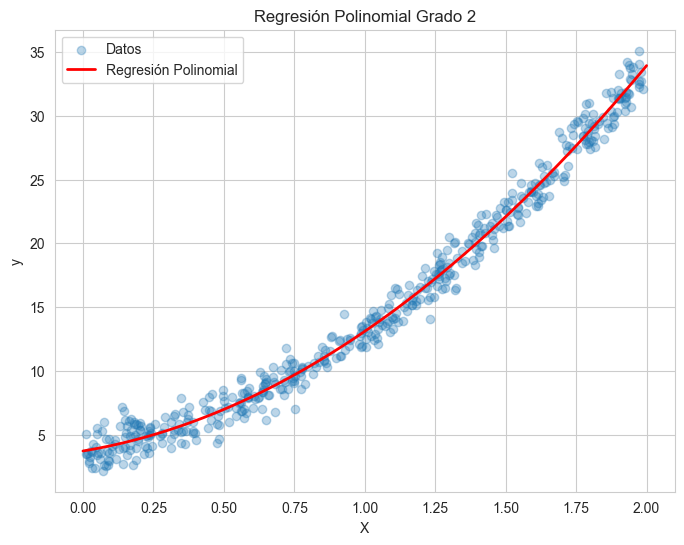

In [10]:
# Generar datos polinomiales
np.random.seed(42)
N = 500
X_poly = 2 * np.random.rand(N, 1)
y_poly = 4 + 3 * X_poly + 6 * X_poly**2 + np.random.randn(N, 1)

# Construir matriz de diseño polinomial (grado 2)
A_poly = np.hstack((np.ones((len(X_poly), 1)), X_poly, X_poly**2))

# Calcular coeficientes
w_poly = np.linalg.pinv(A_poly) @ y_poly

print(f"Coeficientes polinomiales: w0 = {w_poly[0,0]:.4f}, w1 = {w_poly[1,0]:.4f}, w2 = {w_poly[2,0]:.4f}")
print(f"Coeficientes reales: w0 = 4.0000, w1 = 3.0000, w2 = 6.0000")

# Visualizar
X_pred_poly = np.linspace(0, 2, 100).reshape(-1, 1)
X_pred_poly_bias = np.hstack((np.ones((len(X_pred_poly), 1)), X_pred_poly, X_pred_poly**2))
y_pred_poly = X_pred_poly_bias @ w_poly

plt.figure(figsize=(8, 6))
plt.scatter(X_poly, y_poly, alpha=0.3, label='Datos')
plt.plot(X_pred_poly, y_pred_poly, 'r-', linewidth=2, label='Regresión Polinomial')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regresión Polinomial Grado 2')
plt.legend()
plt.show()

## 3. Gradiente Descendente

In [11]:
# Datos sintéticos
np.random.seed(42)
N = 500
X = 2 * np.random.rand(N, 1)
y = 4 + 3 * X + np.random.randn(N, 1)

# Matriz de diseño
A = np.hstack((np.ones((len(X), 1)), X))

# Parámetros de GD
lr = 0.1  # Tasa de aprendizaje
n_iteraciones = 1000
m = len(A)

# Inicializar pesos
w_gd = np.random.randn(2, 1)

# Lista para almacenar la pérdida
loss_history = []

# Gradiente Descendente
for i in range(n_iteraciones):
    gradiente = 2/m * A.T @ (A @ w_gd - y)
    w_gd = w_gd - lr * gradiente
    ye = w_gd[0] + w_gd[1] * X
    errores = (ye - y)**2
    loss_history.append(np.sum(errores))

print(f"Coeficientes GD: w0 = {w_gd[0,0]:.4f}, w1 = {w_gd[1,0]:.4f}")
print(f"Coeficientes reales: w0 = 4.0000, w1 = 3.0000")

Coeficientes GD: w0 = 3.8929, w1 = 3.1150
Coeficientes reales: w0 = 4.0000, w1 = 3.0000


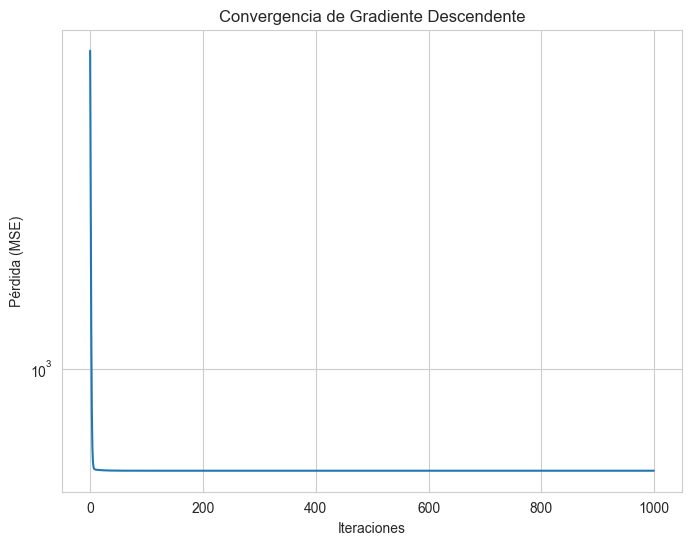

In [12]:
# Visualizar pérdida
plt.figure(figsize=(8, 6))
plt.plot(loss_history)
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (MSE)')
plt.title('Convergencia de Gradiente Descendente')
plt.yscale('log')
plt.grid(True)
plt.show()

In [13]:
from sklearn.linear_model import SGDRegressor

# Crear y entrenar SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, eta0=0.1, random_state=42)
sgd_reg.fit(X, y.ravel())

print(f"Coeficientes SGD: w0 = {sgd_reg.intercept_[0]:.4f}, w1 = {sgd_reg.coef_[0]:.4f}")
print(f"Coeficientes reales: w0 = 4.0000, w1 = 3.0000")
print(f"R^2 Score: {sgd_reg.score(X, y):.4f}")

Coeficientes SGD: w0 = 3.8849, w1 = 3.1475
Coeficientes reales: w0 = 4.0000, w1 = 3.0000
R^2 Score: 0.7741


h:\Anaconda\envs\deepf\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\yoda\AppData\Local\Temp\ipykernel_13924\1537012648.py:13: RuntimeWarning: overflow encountered in square
  errores = (ye - y)**2
C:\Users\yoda\AppData\Local\Temp\ipykernel_13924\1537012648.py:12: RuntimeWarning: overflow encountered in multiply
  ye = w[0] + w[1] * X
C:\Users\yoda\AppData\Local\Temp\ipykernel_13924\1537012648.py:12: RuntimeWarning: overflow encountered in add
  ye = w[0] + w[1] * X
C:\Users\yoda\AppData\Local\Temp\ipykernel_13924\1537012648.py:10: RuntimeWarning: overflow encountered in matmul
  gradiente = 2/m * A.T @ (A @ w - y)
C:\Users\yoda\AppData\Local\Temp\ipykernel_13924\1537012648.py:11: RuntimeWarning: invalid value encountered in subtract
  w = w - lr * gradiente
h:\Anaconda\envs\deepf\lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  

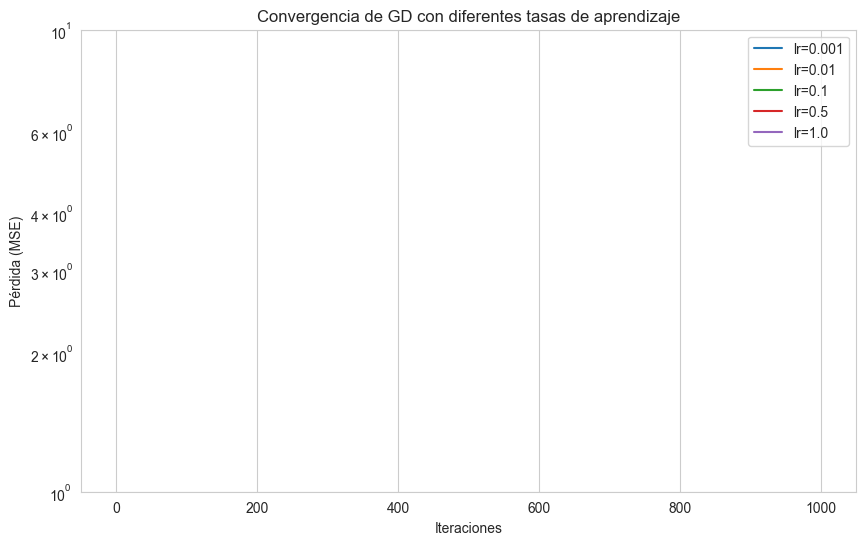

In [14]:
# Comparar diferentes learning rates
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    w = np.random.randn(2, 1)
    loss_hist = []
    for i in range(n_iteraciones):
        gradiente = 2/m * A.T @ (A @ w - y)
        w = w - lr * gradiente
        ye = w[0] + w[1] * X
        errores = (ye - y)**2
        loss_hist.append(np.sum(errores))
    plt.plot(loss_hist, label=f'lr={lr}')

plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (MSE)')
plt.title('Convergencia de GD con diferentes tasas de aprendizaje')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

## 4. Ejemplo con Datos de Ventas

In [15]:
# Cargar datos de ventas
import pandas as pd
data = pd.read_csv('Ventas.csv', index_col=0)

# Mostrar primeras filas
print("Primeras 5 filas:")
data.head()

Primeras 5 filas:


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [16]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
data.describe()

Estadísticas descriptivas:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [17]:
# Matriz de correlación
print("Matriz de correlación:")
data.corr()

Matriz de correlación:


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


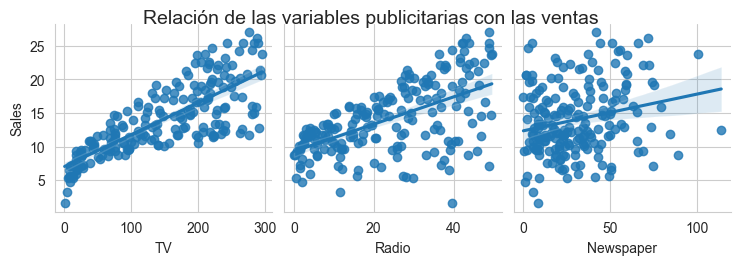

In [18]:
# Pairplot
sns.pairplot(data, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', kind='reg')
plt.suptitle('Relación de las variables publicitarias con las ventas', y=1.02, fontsize=14)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Seleccionar características y objetivo
feature_cols = ['TV', 'Radio', 'Newspaper']
X = data[feature_cols]
y = data['Sales']

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Entrenar modelo
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Coeficientes
print("Coeficientes:")
for name, coef in zip(feature_cols, linreg.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercepto: {linreg.intercept_:.4f}")
print(f"\nEcuación: Sales = {linreg.intercept_:.2f} + {linreg.coef_[0]:.4f}*TV + {linreg.coef_[1]:.4f}*Radio + {linreg.coef_[2]:.4f}*Newspaper")

Coeficientes:
  TV: 0.0466
  Radio: 0.1792
  Newspaper: 0.0035
Intercepto: 2.8770

Ecuación: Sales = 2.88 + 0.0466*TV + 0.1792*Radio + 0.0035*Newspaper


In [20]:
# Predecir en test
y_pred = linreg.predict(X_test)

# Calcular métricas
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 1.0669
MSE: 1.9730
RMSE: 1.4047


In [21]:
# Modelo sin Newspaper
feature_cols_simple = ['TV', 'Radio']
X_simple = data[feature_cols_simple]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y, random_state=1)

linreg_simple = LinearRegression()
linreg_simple.fit(X_train_simple, y_train_simple)

y_pred_simple = linreg_simple.predict(X_test_simple)
rmse_simple = np.sqrt(metrics.mean_squared_error(y_test_simple, y_pred_simple))

print(f"RMSE con todas las variables: {rmse:.4f}")
print(f"RMSE sin Newspaper: {rmse_simple:.4f}")
print(f"\nMejora: {rmse - rmse_simple:.4f}")

print("\nCoeficientes del modelo simplificado:")
for name, coef in zip(feature_cols_simple, linreg_simple.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercepto: {linreg_simple.intercept_:.4f}")

RMSE con todas las variables: 1.4047
RMSE sin Newspaper: 1.3879

Mejora: 0.0167

Coeficientes del modelo simplificado:
  TV: 0.0466
  Radio: 0.1812
Intercepto: 2.9272


**Conclusión:** Newspaper no mejora el modelo y puede eliminarse.

## 5. El Problema de las Escalas

In [22]:
# Cargar California Housing
X_cal, y_cal = fetch_california_housing(return_X_y=True)

# Agregar columna de unos
X_bias = np.c_[np.ones((X_cal.shape[0], 1)), X_cal]

# Calcular número de condición
cond_number = np.linalg.cond(X_bias.T @ X_bias)

print(f"Número de condición: {cond_number:.2e}")
print("\nInterpretación:")
print("- κ >> 1: Mal condicionado")
print("- La matriz X^T X está casi singular")
print("- La inversión es numéricamente inestable")

Número de condición: 5.68e+10

Interpretación:
- κ >> 1: Mal condicionado
- La matriz X^T X está casi singular
- La inversión es numéricamente inestable


In [23]:
# Entrenar modelo con datos crudos
model_raw = LinearRegression()
model_raw.fit(X_cal, y_cal)

# Mostrar coeficientes
feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
print("Coeficientes con datos crudos:")
for name, coef in zip(feature_names, model_raw.coef_):
    print(f"  {name}: {coef:.6f}")

Coeficientes con datos crudos:
  MedInc: 0.436693
  HouseAge: 0.009436
  AveRooms: -0.107322
  AveBedrms: 0.645066
  Population: -0.000004
  AveOccup: -0.003787
  Latitude: -0.421314
  Longitude: -0.434514


**Observación:** Los coeficientes no son comparables porque las variables tienen escalas muy diferentes.

## 6. Normalización como Solución

In [24]:
from sklearn.preprocessing import StandardScaler

# Crear y aplicar scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cal)

# Calcular nuevo número de condición
X_scaled_bias = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]
cond_scaled = np.linalg.cond(X_scaled_bias.T @ X_scaled_bias)

print(f"Número de condición (original): {cond_number:.2e}")
print(f"Número de condición (normalizado): {cond_scaled:.2f}")
print(f"\nMejora: factor de {cond_number/cond_scaled:.2e}")

Número de condición (original): 5.68e+10
Número de condición (normalizado): 44.47

Mejora: factor de 1.28e+09


In [25]:
# Entrenar modelo con datos normalizados
model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y_cal)

# Mostrar coeficientes
print("Coeficientes con datos normalizados:")
for name, coef in zip(feature_names, model_scaled.coef_):
    print(f"  {name}: {coef:.4f}")

# Comparar RMSE
y_pred_raw = model_raw.predict(X_cal)
y_pred_scaled = model_scaled.predict(X_scaled)

rmse_raw = np.sqrt(metrics.mean_squared_error(y_cal, y_pred_raw))
rmse_scaled = np.sqrt(metrics.mean_squared_error(y_cal, y_pred_scaled))

print(f"\nRMSE (datos crudos): {rmse_raw:.4f}")
print(f"RMSE (datos normalizados): {rmse_scaled:.4f}")

Coeficientes con datos normalizados:
  MedInc: 0.8296
  HouseAge: 0.1188
  AveRooms: -0.2655
  AveBedrms: 0.3057
  Population: -0.0045
  AveOccup: -0.0393
  Latitude: -0.8999
  Longitude: -0.8705

RMSE (datos crudos): 0.7241
RMSE (datos normalizados): 0.7241


**Observaciones:**
- Los coeficientes normalizados son comparables entre sí
- Ahora podemos ver que Latitude y Longitude tienen el mayor impacto (en valor absoluto)
- El RMSE es prácticamente el mismo, pero la interpretabilidad mejora significativamente

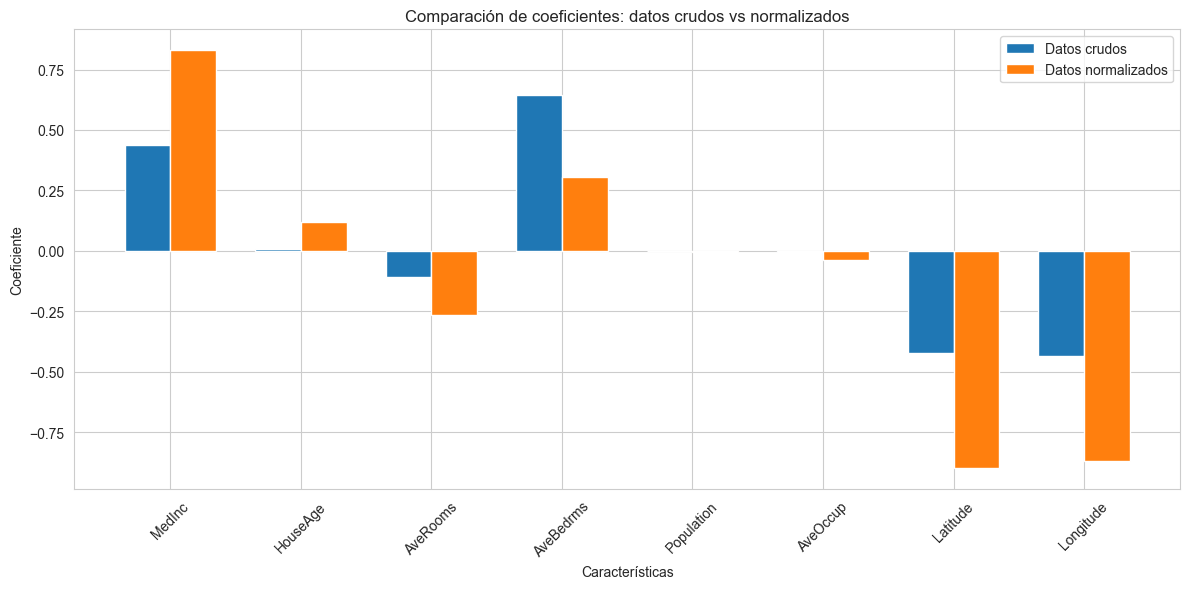

In [26]:
# Comparación visual de coeficientes
plt.figure(figsize=(12, 6))

x = np.arange(len(feature_names))
width = 0.35

plt.bar(x - width/2, model_raw.coef_, width, label='Datos crudos')
plt.bar(x + width/2, model_scaled.coef_, width, label='Datos normalizados')

plt.xlabel('Características')
plt.ylabel('Coeficiente')
plt.title('Comparación de coeficientes: datos crudos vs normalizados')
plt.xticks(x, feature_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Visualizar el impacto de la normalización en SGD
from sklearn.linear_model import SGDRegressor

# Datos sintéticos con escalas diferentes
np.random.seed(42)
N = 500
X1 = 1000 * np.random.rand(N, 1)  # Escala grande
X2 = 0.001 * np.random.rand(N, 1)  # Escala pequeña
X_mixed = np.hstack((X1, X2))
y_mixed = 2 * X1 + 3 * X2 + np.random.randn(N, 1)

# SGD con datos crudos
sgd_raw = SGDRegressor(max_iter=1000, eta0=0.1, random_state=42)
sgd_raw.fit(X_mixed, y_mixed.ravel())

# Normalizar
scaler_mixed = StandardScaler()
X_mixed_scaled = scaler_mixed.fit_transform(X_mixed)

# SGD con datos normalizados
sgd_scaled = SGDRegressor(max_iter=1000, eta0=0.1, random_state=42)
sgd_scaled.fit(X_mixed_scaled, y_mixed.ravel())

print("Comparación de SGD con y sin normalización:")
print(f"Coeficientes (crudos): w1 = {sgd_raw.coef_[0]:.4f}, w2 = {sgd_raw.coef_[1]:.4f}")
print(f"Coeficientes (normalizados): w1 = {sgd_scaled.coef_[0]:.4f}, w2 = {sgd_scaled.coef_[1]:.4f}")
print(f"\nIteraciones (crudos): {sgd_raw.n_iter_}")
print(f"Iteraciones (normalizados): {sgd_scaled.n_iter_}")

Comparación de SGD con y sin normalización:
Coeficientes (crudos): w1 = 938489497624.7036, w2 = -211800746.4214
Coeficientes (normalizados): w1 = 596.6167, w2 = 0.0999

Iteraciones (crudos): 61
Iteraciones (normalizados): 13


## 7. Resumen Final

**Puntos clave:**

1. **Regresión Lineal Multivariada:** $\hat{y} = \mathbf{w}^T\mathbf{x} + b$

2. **Ecuación Normal:** $\hat{\mathbf{w}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$
   - Solución directa, O(n^3) para la inversión
   - Inestable si $\mathbf{X}^T\mathbf{X}$ está mal condicionado

3. **Gradiente Descendente:** $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla J(\mathbf{w})$
   - Iterativo, O(n) por iteración
   - Requiere elegir la tasa de aprendizaje

4. **El problema de las escalas:**
   - Variables con diferentes magnitudes distorsionan la superficie de costo
   - Afecta la convergencia de GD
   - Hace que los coeficientes no sean comparables

5. **Normalización (StandardScaler):** $x' = \frac{x - \mu}{\sigma}$
   - Mejora el condicionamiento de $\mathbf{X}^T\mathbf{X}$
   - Acelera la convergencia de GD
   - Hace que los coeficientes sean interpretables

6. **Regla de oro:** ¡Siempre preprocesar los datos antes de entrenar!